In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
IMG_SIZE = 128
PATCH_SIZE = 16
NUM_CLASSES = 2
BATCH_SIZE = 32
EPOCHS = 50

In [3]:
def extract_patches(images, patch_size=16):
    patches = tf.image.extract_patches(
        images=images,
        sizes=[1, patch_size, patch_size, 1],
        strides=[1, patch_size, patch_size, 1],
        rates=[1, 1, 1, 1],
        padding='VALID'
    )
    
    patches = tf.reshape(
        patches,
        (patches.shape[0], patches.shape[1] * patches.shape[2], patches.shape[3])
    )
    return patches

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    r"C:\Users\shaya\Downloads\archive\cell_images",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset="training",
    class_mode="categorical"
)

val_generator = train_datagen.flow_from_directory(
    r"C:\Users\shaya\Downloads\archive\cell_images",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset="validation",
    class_mode="categorical"
)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


In [5]:
def build_cnn_bilstm_model(patch_vector, num_patches, num_classes):
    
    model = Sequential([
        Input(shape=(num_patches, patch_vector)),
        
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.4),

        Bidirectional(LSTM(32)),
        Dropout(0.4),
        
        Dense(64, activation='relu'),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(1e-4),
        metrics=['accuracy']
    )
    
    return model

In [6]:
batch_x, batch_y = next(train_generator)

patches = extract_patches(batch_x, PATCH_SIZE)
num_patches = patches.shape[1]
patch_vector = patches.shape[2]

model = build_cnn_bilstm_model(patch_vector, num_patches, NUM_CLASSES)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 64, 128)             │         426,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 472,002 (1.80 MB)

 Trainable params: 472,002 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
def generator_with_patches(gen):
    while True:
        x, y = next(gen)
        yield extract_patches(x, PATCH_SIZE), y

history = model.fit(
    generator_with_patches(train_generator),
    steps_per_epoch=len(train_generator),
    validation_data=generator_with_patches(val_generator),
    validation_steps=len(val_generator),
    epochs=EPOCHS
)

Epoch 1/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 404s 578ms/step - accuracy: 0.5653 - loss: 0.6835 - val_accuracy: 0.5230 - val_loss: 0.6919
Epoch 2/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 207s 300ms/step - accuracy: 0.5966 - loss: 0.6679 - val_accuracy: 0.6392 - val_loss: 0.6332
Epoch 3/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 261s 379ms/step - accuracy: 0.6198 - loss: 0.6575 - val_accuracy: 0.5811 - val_loss: 0.6505
Epoch 4/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 211s 306ms/step - accuracy: 0.6221 - loss: 0.6547 - val_accuracy: 0.6114 - val_loss: 0.6457
Epoch 5/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 206s 300ms/step - accuracy: 0.6336 - loss: 0.6497 - val_accuracy: 0.5904 - val_loss: 0.6522
Epoch 6/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 250s 363ms/step - accuracy: 0.6377 - loss: 0.6449 - val_accuracy: 0.6563 - val_loss: 0.6255
Epoch 7/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 178s 259ms/step - accuracy: 0.6385 - loss: 0.6424 - val_accuracy: 0.6848 - val_loss: 0.6081
Epoch 8/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 170s 247ms/step - accuracy: 0.6395 -

In [8]:
val_loss, val_acc = model.evaluate(generator_with_patches(val_generator), steps=len(val_generator))
print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)

173/173 ━━━━━━━━━━━━━━━━━━━━ 70s 408ms/step - accuracy: 0.8662 - loss: 0.3103
Validation Accuracy: 0.8662431836128235
Validation Loss: 0.31028905510902405


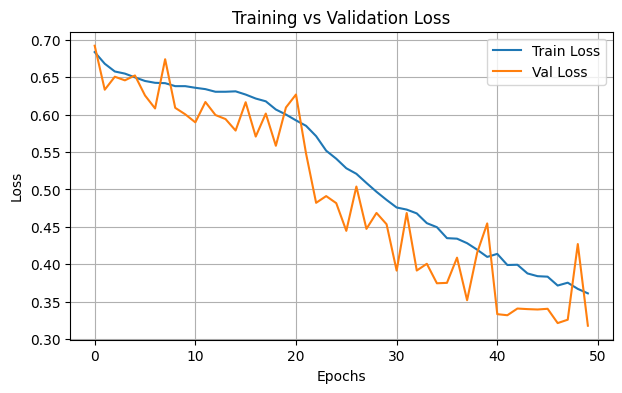

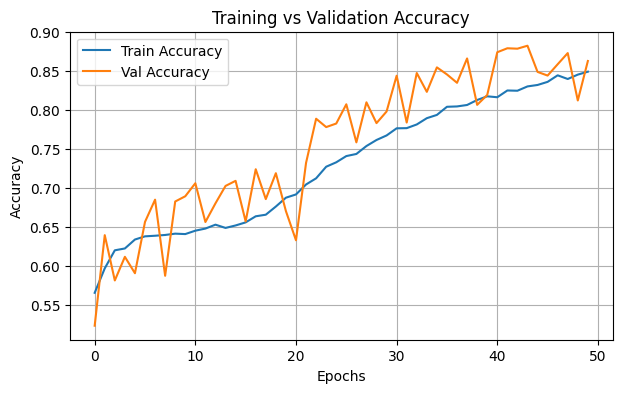

In [9]:
import matplotlib.pyplot as plt

# LOSS CURVE
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ACCURACY CURVE
plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

173/173 ━━━━━━━━━━━━━━━━━━━━ 72s 407ms/step


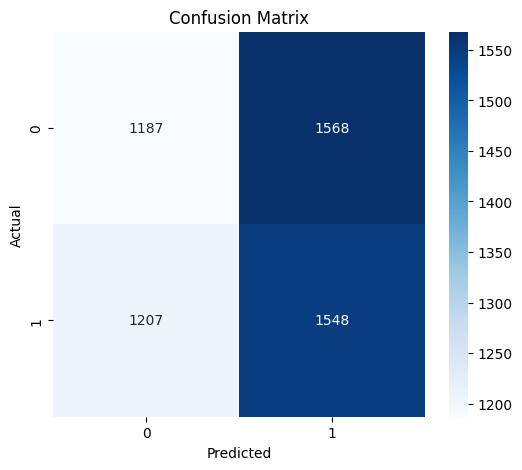


Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.43      0.46      2755
           1       0.50      0.56      0.53      2755

    accuracy                           0.50      5510
   macro avg       0.50      0.50      0.49      5510
weighted avg       0.50      0.50      0.49      5510



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get true labels
y_true = val_generator.classes

# Predict on validation set
pred_probs = model.predict(generator_with_patches(val_generator), steps=len(val_generator))
y_pred = np.argmax(pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))